# Дані:

In [ ]:
import seaborn as sns

df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# ✅ Очікуване подання результатів:

* Графіки з заголовками, підписами, поясненнями та короткими висновками (1-2 речення після графіку).
  * Що показує графік? (простою мовою)
  * Які закономірності чи тенденції ми бачимо?
  * Що це може означати або спонукати нас до подальшого дослідження?
* Мінімум 6 візуалізацій, різних типів.

Приклад графіка та пояснення:

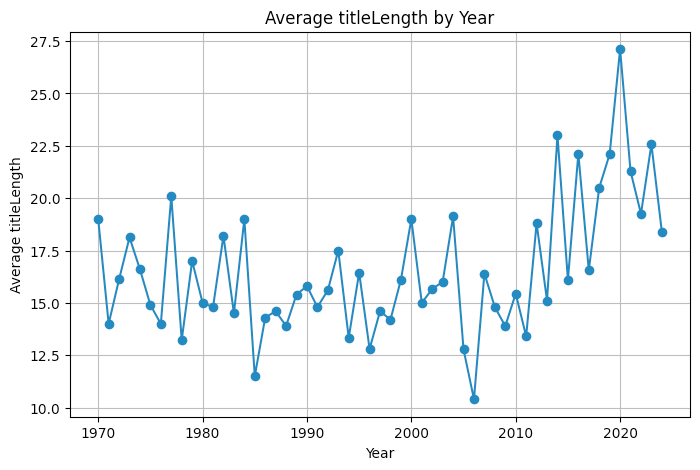

На діаграмі видно, що середня довжина назв книг поступово збільшувалася з 1970-х до 2020-х років, з помітним сплеском після 2010 року. Назви останніх років часто в середньому перевищують 22 символи, досягаючи піку у 2020 році. Це може відображати тенденції до більш описових або маркетингово орієнтованих назв.

# 🔍 Part 1: Data Exploration

* Перевірте, чи є в таблиці пропущені значення, і поясніть, як ви з ними впоралися.
* За допомогою boxplot знайдіть викиди у колонках tip та total_bill.
* Додайте колонку tip_percentage, яка обчислюється як (tip / total_bill) * 100.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


Метод info показує, скільки є в даних не порожніх значень (у даному випадку 244 non-null). Якби були, можна їх замінити через fillna.

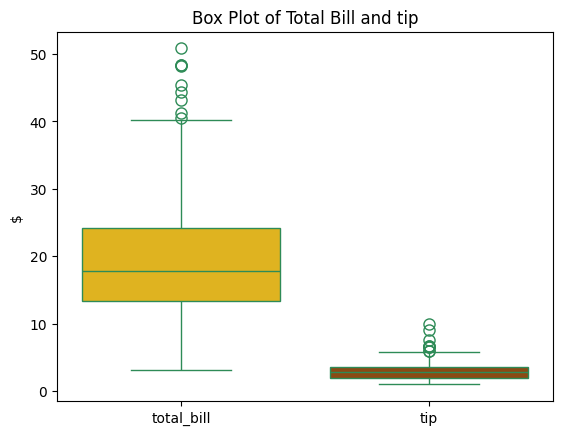

In [ ]:
import matplotlib.pyplot as plt
import random
palette = sns.color_palette('bright', 10)
random.shuffle(palette)
linecolor = 'seagreen'
sns.boxplot(data=df[['total_bill', 'tip']], fliersize=8,
            palette=palette[:2], linecolor=linecolor)
plt.ylabel('$')
plt.title('Box Plot of Total Bill and tip')
plt.show()

На графіку видно, що кількість аномально високих чеків і чайових орієнтовно корелюються між собою (3-4% "на око" від загальної кількості даних). Тобто люди, які готові заплатити за їжу більше, більше готові давати чайових.

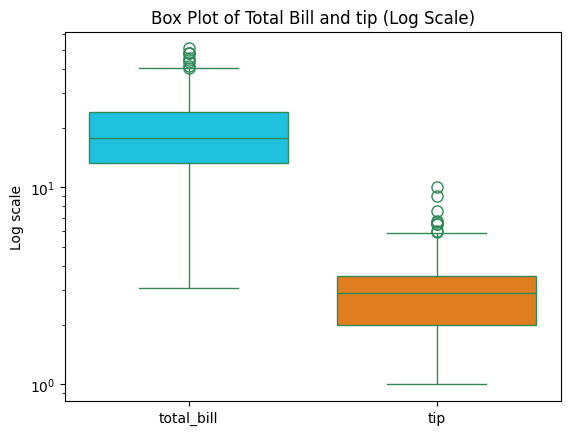

In [ ]:
random.shuffle(palette)
linecolor = 'seagreen'
ax = sns.boxplot(data=df[['total_bill', 'tip']], fliersize=8,
            palette=palette[:2], linecolor=linecolor)
ax.set_yscale("log")
plt.ylabel('Log scale')
plt.title('Box Plot of Total Bill and tip (Log Scale)')
plt.show()


Логарифмічна шкала допомагає бачити, що розбіжність значеннь аномально високих чеків менша за середній чек.
Тобто люди, які платять більше за їжу, знаходяться в однаковій "чековій ніші", яка в два рази вища за середній чек.
У чайових же - розбіжність аномальних високих значень однакова з середнім розміром чайових.
Люди, які платять аномально високі чайові, можуть заплатити у межах від 2 до 3 разів більше за середні чайові.

In [ ]:
df['tip_percentage'] = (df['tip'] / df['total_bill']) * 100
df.head()

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


# 📊 Part 2: Візуалізації


* boxplot або violinplot: Хто дає більше чайових: чоловіки чи жінки?

* barplot або pointplot з estimator='mean': Як розмір компанії впливає на розмір чайових? (Вивчіть залежність tip та tip_percentage від size.)

* boxplot, stripplot або histplot: Курці vs. Некурці — хто щедріший? Порівняйте чайові між smoker = "Yes" та "No".

* barplot або catplot(kind='box'): Який день тижня найвигідніший? Порівняйте середні значення tip та tip_percentage по колонці day.

* boxplot або barplot: Обід проти вечері — коли чайові вищі? Порівняйте значення tip і tip_percentage між time = Lunch та Dinner.

* histplot або kdeplot для tip_percentage: Розподіл відсотка чайових. Проаналізуйте, як часто відвідувачі дають щедрі чайові.

* boxplot або violinplot по колонці time: Чи впливає час доби на розмір рахунку?
Дослідіть, чи є суттєва різниця в total_bill між Lunch та Dinner.

* scatterplot або regplot: Залежність чайових від розміру рахунку?
Чи існує кореляція між total_bill та tip?


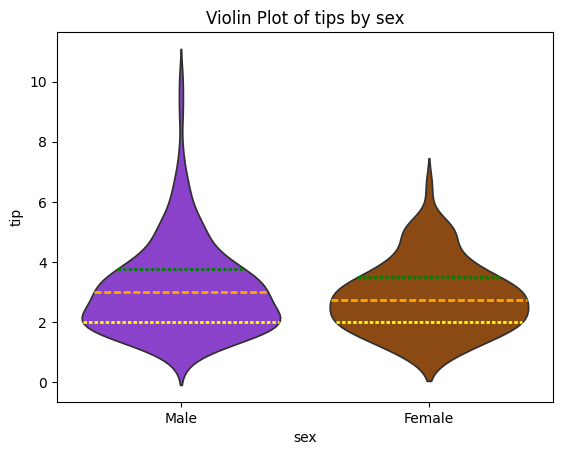

In [ ]:
random.shuffle(palette)
ax = sns.violinplot(data=df, x='sex', y='tip', hue='sex', inner='quartile', palette=palette[:2])
quartile_lines = ax.get_lines()
colors = ['yellow', 'orange', 'green'] * 2
for line, color in zip(quartile_lines, colors):
    line.set_color(color)
    line.set_linewidth(2)
plt.title('Violin Plot of tips by sex')
plt.show()

Хвостик буряка чоловічої статі, який виткнувся після морозів напровесні, доводить, що чоловіки, як і підтверджує це графік, можуть бути щедрішими за жінок, у поодиноких випадках, хоча в більшості вони чекають потепління, на одному середньому рівні з жінками.

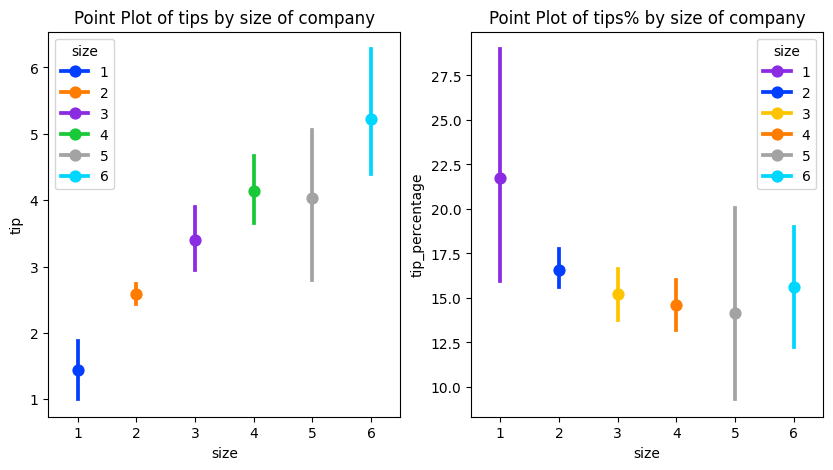

In [ ]:
random.shuffle(palette)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.pointplot(data=df, x='size', y='tip', hue='size',
              estimator='mean', palette=palette[:6], ax=axes[0])
axes[0].set_title('Point Plot of tips by size of company')
random.shuffle(palette)
sns.pointplot(data=df, x='size', y='tip_percentage', hue='size', estimator='mean', palette=palette[:6], ax=axes[1])
axes[1].set_title('Point Plot of tips% by size of company')
fig.show()

Як видно на першому (зліва) графіку, кількість людей в компанії за столиком, майже пропорційно впливає на суму чайових (більше людей - більша сума чайових). У той же час другий графік показує, що відсоткове співвідношення чайових до розміру компанії падає (частіше чайові дають не всі люди із компанії).

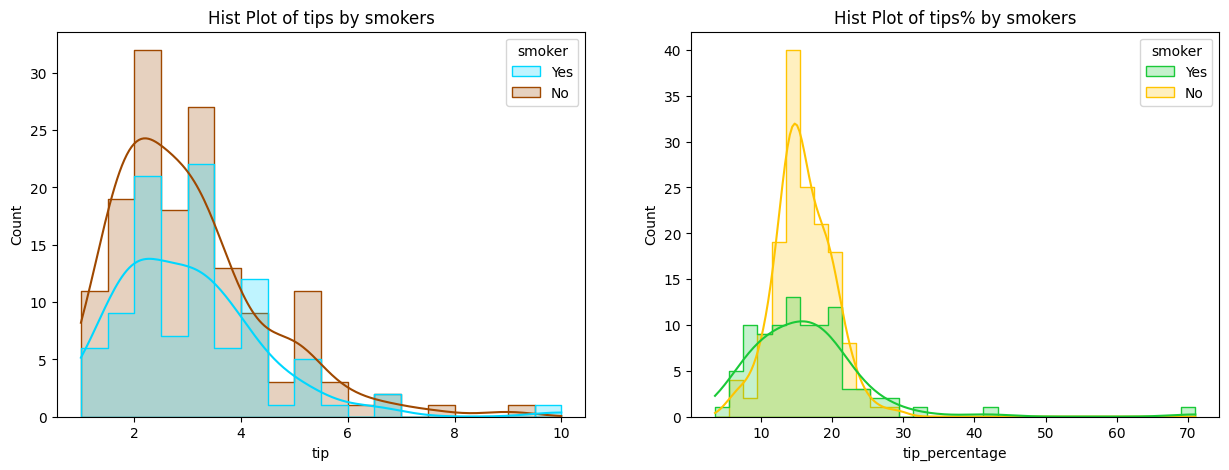

In [ ]:
random.shuffle(palette)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=df, x='tip', hue='smoker', kde=True,
             palette=palette[:2], element="step", ax=axes[0])
axes[0].set_title('Hist Plot of tips by smokers')
random.shuffle(palette)
sns.histplot(data=df, x='tip_percentage', hue='smoker', kde=True,
             palette=palette[:2], element="step", ax=axes[1],
             common_norm=False)
axes[1].set_title('Hist Plot of tips% by smokers')
fig.show()

Лівий графік показує, що кількість не курців, які дають більше за звичайну суму чайових, перевищує кількість курців. Але це може бути повязано зі статистичною вибіркою, у якій загальна кількість курців менша за кількість не курців. А от правий графік вже наочно показує, що курці щедріші у співвідношенні чайових до загального чеку замовлення (вони помітно частіше дають більший відсоток - >30% - чайових). У той час не курці у більшості, здебільшого дають передбачуваний відсоток ~10-23% чайових.

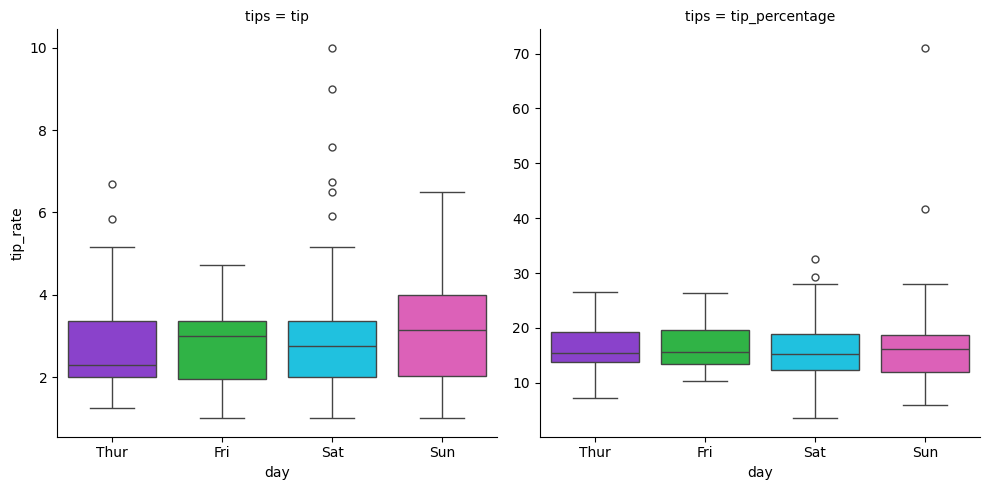

In [ ]:
import pandas as pd
random.shuffle(palette)
melted_data = pd.melt(df,
                    id_vars=['day'],
                    value_vars=['tip','tip_percentage'],
                    var_name='tips',
                    value_name='tip_rate')
sns.catplot(data=melted_data,
            x='day',
            y='tip_rate',
            col='tips',
            hue='day',
            legend=False,
            kind='box',
            palette=palette[:4],
            sharey=False)
plt.show()

Якщо дивитись абсолютні значення (лівий графік), найвигіднішими днями тижня є вихідні - субота та неділя. У суботу середнє значення чайових трохи нижче, проте наявні надвисокі чайові. У неділю ж підвищений середній рівень чайових. Правий графік із часткою чайових від чеку так само показує для неділі підвищений середній рівень чайових і поодинокі аномально високі частки чайових.

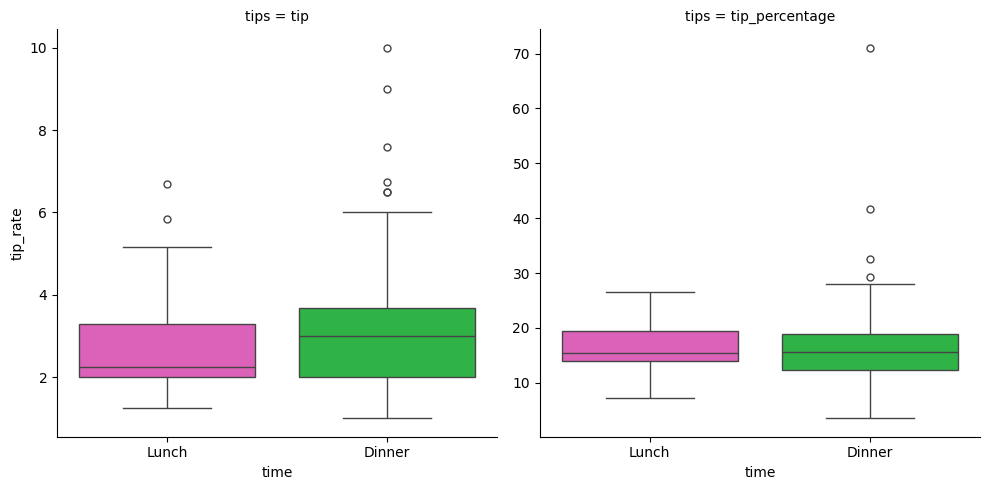

In [ ]:
random.shuffle(palette)
melted_data = pd.melt(df,
                    id_vars=['time'],
                    value_vars=['tip','tip_percentage'],
                    var_name='tips',
                    value_name='tip_rate')
sns.catplot(data=melted_data,
            x='time',
            y='tip_rate',
            col='tips',
            hue='time',
            legend=False,
            kind='box',
            palette=palette[:2],
            sharey=False)
plt.show()

Лівий графік показує значну перевагу чайових під час вечері - абсолютне середнє значення, із наявністю аномально високих чайових. Відсоткове ж співвідношення чайових до загального чеку на правому графіку майже не відрізняється для обіду та вечері, проте увечері наявні аномально високі відсотки.

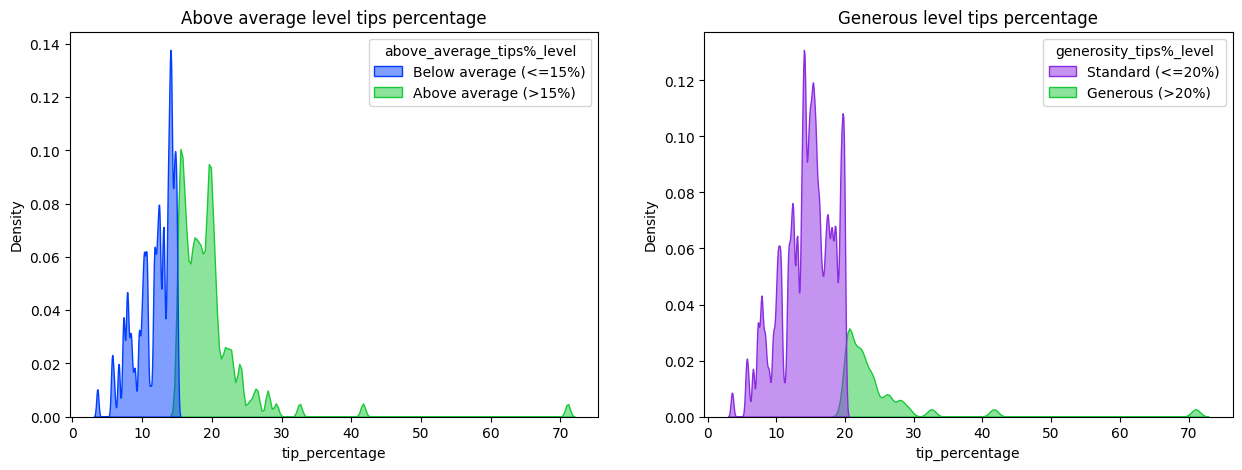

In [ ]:
import numpy as np
random.shuffle(palette)
df['above_average_tips%_level'] = np.where(df['tip_percentage'] > 15, 'Above average (>15%)', 'Below average (<=15%)')
df['generosity_tips%_level'] = np.where(df['tip_percentage'] > 20, 'Generous (>20%)', 'Standard (<=20%)')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.kdeplot(
    data=df,
    x='tip_percentage',
    hue='above_average_tips%_level',
    fill=True,
    palette={'Above average (>15%)': palette[0], 'Below average (<=15%)': palette[1]},
    alpha=0.5,
    bw_adjust=0.15,
    ax=axes[0])
axes[0].set_title('Above average level tips percentage')
random.shuffle(palette)
sns.kdeplot(
    data=df,
    x='tip_percentage',
    hue='generosity_tips%_level',
    fill=True,
    palette={'Generous (>20%)': palette[0], 'Standard (<=20%)': palette[1]},
    alpha=0.5,
    bw_adjust=0.15,
    ax=axes[1])
axes[1].set_title('Generous level tips percentage')
fig.show()

З графіків видно, що більшість чайових лежать в межах до 15% від чеку, і вже після 20% чайові складають поодинокі випадки серед загалу.

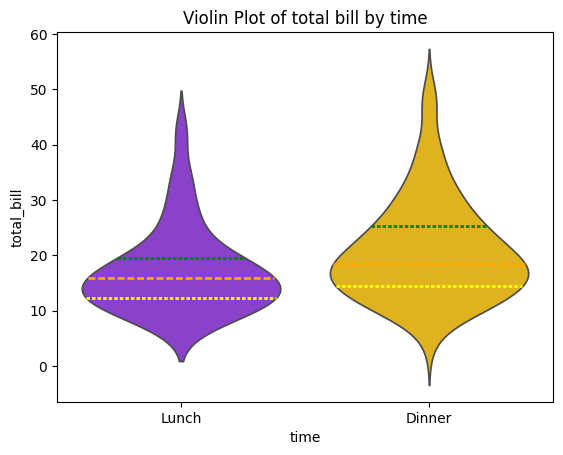

In [ ]:
random.shuffle(palette)
ax = sns.violinplot(data=df, x='time', y='total_bill', hue='time', inner='quartile', palette=palette[:2])
quartile_lines = ax.get_lines()
colors = ['yellow', 'orange', 'green'] * 2
for line, color in zip(quartile_lines, colors):
    line.set_color(color)
    line.set_linewidth(2)
plt.title('Violin Plot of total bill by time')
plt.show()

Графік показує, що всі показники (25 персентиль, середній чек, та 75 пересентиль особливо), мають вище значення для вечірніх чеків - напевне люди у цей час довше сидять за столом і більшими компаніями, це час дозвілля, а не робочих перекусів, як в обід.

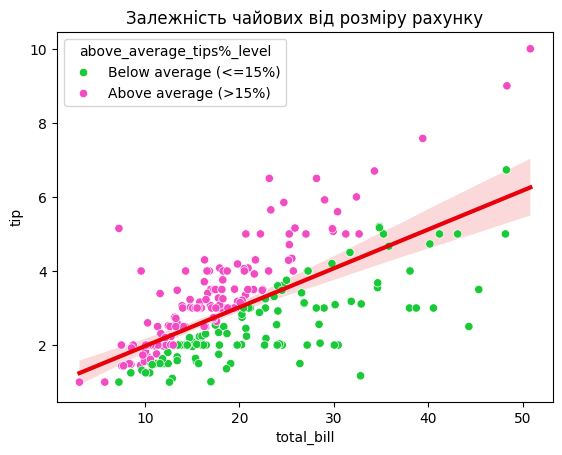

In [ ]:
random.shuffle(palette)
sns.regplot(
    data=df,
    x='total_bill',
    y='tip',
    line_kws={'color':palette[0], 'lw': 3},
    scatter=False
)
sns.scatterplot(
    data=df,
    x='total_bill',
    y='tip',
    hue='above_average_tips%_level',
    palette={'Above average (>15%)': palette[1], 'Below average (<=15%)': palette[2]}
)
plt.title('Залежність чайових від розміру рахунку')
plt.show()

Графік чітко визначає, що існує кореляція між розміром рахунку, розміром та відсотком чайових. Сума чайових концентрується навколо середньої висхідної лінії, яка майже рівномірно розділяє кількість чеків із середнім та меншим відсотком чайових, та відсотком чайових вище середнього.

# 💬 Part 3: Аналіз

Коротко проаналізуйте, базуючись на даних:

* Коли відвідувачі залишають більші чайові — обід чи вечеря? Чому так може бути?

* Які фактори найбільше впливають на щедрість відвідувачів (tip_percentage)?
(Наприклад: день тижня, стать, куріння, розмір групи...)

* Чи є ознаки змін у поведінці відвідувачів у різні дні тижня?
(Виберіть 1–2 цікаві закономірності, які ви виявили)

In [ ]:
mean_tip_by_time = (df.groupby('time', observed=False)['tip'].mean().
                sort_values(ascending=False).
                rename(index={'Lunch': 'обіду', 'Dinner': 'вечері'}))
print(f'Більші чайові відвідувачі залишають під час {mean_tip_by_time.index[0]}'
      f' (в середньому {mean_tip_by_time.iloc[0]:.2f}) - напевне люди у цей час довше сидять за столом і більшими компаніями, '
      f'це час дозвілля, а не робочих перекусів, як під час {mean_tip_by_time.index[1]} (в середньому {mean_tip_by_time.iloc[1]:.2f}).'
      )


Більші чайові відвідувачі залишають під час вечері (в середньому 3.10) - напевне люди у цей час довше сидять за столом і більшими компаніями, це час дозвілля, а не робочих перекусів, як під час обіду (в середньому 2.73).


In [ ]:
factors = {k: v for k, v in zip(df.columns.tolist()[2:7], {'стать', 'курець', 'день тижня', 'час', 'розмір компанії'})}
impacts = {}
for f in factors:
  factor_means = df.groupby(f, observed=False)['tip_percentage'].mean()
  impacts[factors[f]] = factor_means.max() - factor_means.min() #розмах впливу
sorted_factors = sorted(impacts.items(), key=lambda x: x[1], reverse=True)
print(f'Найбільший вплив на щедрість відвідувачів (tip_percentage) має "{sorted_factors[0][0]}" '
      f'(розмах впливу {sorted_factors[0][1]:.2f}%), '
      f'другим фактором за величиною розмаху впливу є "{sorted_factors[1][0]}" '
      f'із значенням розмаху {sorted_factors[1][1]:.2f}%'
)


Найбільший вплив на щедрість відвідувачів (tip_percentage) має "день тижня" (розмах впливу 7.58%), другим фактором за величиною розмаху впливу є "курець" із значенням розмаху 1.68%


In [ ]:
df.head()


,total_bill,tip,sex,smoker,day,time,size,tip_percentage
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


In [ ]:
day_stats = df.groupby('day', observed=False)[['total_bill', 'tip', 'size', 'tip_percentage']].mean()
print(day_stats)

      total_bill       tip      size  tip_percentage
day                                                 
Thur   17.682742  2.771452  2.451613       16.127563
Fri    17.151579  2.734737  2.105263       16.991303
Sat    20.441379  2.993103  2.517241       15.315172
Sun    21.410000  3.255132  2.842105       16.689729


Найяскравіше видно закономірно високий виторг (середній загальний чек) у вихідні. При цьому цікавим є те, що відсоток чайових у суботу найнижчий серед усіх днів тижня, що повязано із збільшеним у цей день розміром компанії, зазвичай великі компанії дають менший відсоток чайових. Ще одна цікава закономірність - у п'ятницю найвищий відсоток чайових, що якраз підтверджує теорію про яскраве співвідношення розміру компанії (найнижчий серед усіх днів тижня).